## 環境設置

In [1]:
try:
    import openseespy.opensees as ops  # noqa: F401
except ImportError:
    import sys
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops  # noqa: F401

# Case-04:桃園案例——X 向 3 跨 + Y 向 1 跨,真實構架分析

依 [ROADMAP.md](../ROADMAP.md) 規劃,這一步把 Case-02~03.7 驗證過的
方法(剪力構架建模、Demand 物件、Design Loop)真正套進桃園案例的
兩個方向,並跟法規計算文件(`seismic_design_2story_8col.ipynb`)第
15 課用反曲點法算出的估計值(M_1F=22.61 kN-m、M_2F=13.91 kN-m)
交叉比對。

**這次第一次出現真正的多柱構架**:
- X 向:3 跨(18m)、4 柱,前後 2 榀平行
- Y 向:1 跨(6m)、2 柱,4 榀平行(這個已經在 Case-03.5~03.7 用過)

## 第 1 課:從法規計算接力——樓層總力

直接取用 `seismic_design_2story_8col.ipynb` 第 14 課算出的樓層地震力,
不重算——法規計算跟結構分析是兩個獨立驗證過的階段,這裡只是把上一
階段的輸出接成這一階段的輸入。

In [2]:
from dataclasses import dataclass, field

@dataclass
class Demand:
    Pu: float = 0.0
    Mu: float = 0.0
    Vu: float = 0.0
    displacement: float = None
    drift: float = None
    reactions: dict = field(default_factory=dict)


F1_total, F2_total = 39.75, 63.60   # kN, 整棟樓(8柱), 取自seismic_design_2story_8col.ipynb第14課
h1 = h2 = 3.5
DRIFT_LIMIT = 0.005
Pu_gravity = 147.60   # 沿用Case-03.6概估的單柱重力軸力
E_rc = 2.463e7

print(f"整棟樓樓層地震力: F1(2F)={F1_total} kN, F2(屋頂)={F2_total} kN")

整棟樓樓層地震力: F1(2F)=39.75 kN, F2(屋頂)=63.6 kN


## 第 2 課:兩個方向的構架分擔力

- X 向:前後 2 榀平行構架(3跨4柱)平均分攤
- Y 向:4 榀平行構架(1跨2柱)平均分攤(沿用 Case-03.5~03.7)

這裡的「平均分攤」假設本身還沒被驗證——真正的分配比例要等 Case-05
三維模型才算得出來,這裡先接受這個簡化,讓 Case-04 能夠往下走。

In [3]:
n_frames_X, n_col_per_frame_X = 2, 4
n_frames_Y, n_col_per_frame_Y = 4, 2

F1_X, F2_X = F1_total/n_frames_X, F2_total/n_frames_X
F1_Y, F2_Y = F1_total/n_frames_Y, F2_total/n_frames_Y

print(f"X向單榀構架力(3跨4柱): F1={F1_X:.3f} kN, F2={F2_X:.3f} kN")
print(f"Y向單榀構架力(1跨2柱): F1={F1_Y:.3f} kN, F2={F2_Y:.3f} kN")

X向單榀構架力(3跨4柱): F1=19.875 kN, F2=31.800 kN
Y向單榀構架力(1跨2柱): F1=9.938 kN, F2=15.900 kN


## 第 3 課:通用多跨剪力構架建模函式

延伸 Case-03 驗證過的方法(`ops.fix` 拘束轉角+軸向、`ops.equalDOF`
綁定樓板)到任意跨數——不再限於 1 跨 2 柱,可以是 3 跨 4 柱。

In [4]:
def analyze_multibay(h_col, E_mat, span, n_bay, F1_frame, F2_frame):
    """通用多跨剪力構架分析, 回傳第一根柱的Demand(對稱假設下代表全部柱)"""
    Ic = h_col**4/12
    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)

    xs = [i*(span/n_bay) for i in range(n_bay+1)]
    base_nodes, f1_nodes, roof_nodes = [], [], []
    nid = 1
    for x in xs:
        ops.node(nid, x, 0.0); ops.fix(nid, 1,1,1); base_nodes.append(nid); nid += 1
    for x in xs:
        ops.node(nid, x, h1); ops.fix(nid, 0,1,1); f1_nodes.append(nid); nid += 1
    for x in xs:
        ops.node(nid, x, h1+h2); ops.fix(nid, 0,1,1); roof_nodes.append(nid); nid += 1

    for n in f1_nodes[1:]:
        ops.equalDOF(f1_nodes[0], n, 1)
    for n in roof_nodes[1:]:
        ops.equalDOF(roof_nodes[0], n, 1)

    A_big = 1.0e6
    ops.geomTransf('Linear', 1)
    eid = 1
    col_1F_ids = []
    for b, f in zip(base_nodes, f1_nodes):
        ops.element('elasticBeamColumn', eid, b, f, A_big, E_mat, Ic, 1)
        col_1F_ids.append(eid); eid += 1
    for f, r in zip(f1_nodes, roof_nodes):
        ops.element('elasticBeamColumn', eid, f, r, A_big, E_mat, Ic, 1)
        eid += 1

    ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
    ops.load(f1_nodes[0], F1_frame, 0.0, 0.0)
    ops.load(roof_nodes[0], F2_frame, 0.0, 0.0)
    ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Transformation')
    ops.test('NormDispIncr', 1e-10, 20); ops.algorithm('Newton')
    ops.integrator('LoadControl', 1.0); ops.analysis('Static'); ops.analyze(1)

    u1 = ops.nodeDisp(f1_nodes[0], 1); u2 = ops.nodeDisp(roof_nodes[0], 1)
    fcol = ops.eleForce(col_1F_ids[0])
    return Demand(Pu=Pu_gravity, Mu=abs(fcol[2]), Vu=abs(fcol[1]),
                  displacement=u1, drift=u1/h1,
                  reactions={'drift2': (u2-u1)/h2})


def analyze_X(h_col, E_mat):
    return analyze_multibay(h_col, E_mat, span=18.0, n_bay=3, F1_frame=F1_X, F2_frame=F2_X)

def analyze_Y(h_col, E_mat):
    return analyze_multibay(h_col, E_mat, span=6.0, n_bay=1, F1_frame=F1_Y, F2_frame=F2_Y)

print("X向/Y向分析函式定義完成")

X向/Y向分析函式定義完成


## 第 4 課:與反曲點法估計值交叉比對

用 40cm 柱(Case-03.5 最終選定值)重新驗證,跟法規計算文件第 15 課
用反曲點法算出的估計值對照。

In [5]:
demand_X_40 = analyze_X(0.40, E_rc)
demand_Y_40 = analyze_Y(0.40, E_rc)

print(f"X向(40cm): Mu={demand_X_40.Mu:.4f} kN-m")
print(f"Y向(40cm): Mu={demand_Y_40.Mu:.4f} kN-m")
print(f"反曲點法估計(第15課): 1F柱端彎矩=22.61 kN-m")

assert abs(demand_X_40.Mu - 22.61) < 0.01, "X向跟反曲點法估計對不起來!"
assert abs(demand_Y_40.Mu - 22.61) < 0.01, "Y向跟反曲點法估計對不起來!"
print("\n[PASS] 兩個方向的真實構架分析結果都跟反曲點法估計值吻合")
print("(反曲點法當初用的「8柱等剛度均分」假設, 在這個簡化模型下被驗證是合理的)")

X向(40cm): Mu=22.6078 kN-m
Y向(40cm): Mu=22.6078 kN-m
反曲點法估計(第15課): 1F柱端彎矩=22.61 kN-m

[PASS] 兩個方向的真實構架分析結果都跟反曲點法估計值吻合
(反曲點法當初用的「8柱等剛度均分」假設, 在這個簡化模型下被驗證是合理的)


## 第 5 課:一個誠實的發現——兩個方向的需求「幾乎完全相同」

先看結果,再解釋為什麼。

In [6]:
print(f"X向: Mu={demand_X_40.Mu:.6f} kN-m, drift={demand_X_40.drift:.8f}")
print(f"Y向: Mu={demand_Y_40.Mu:.6f} kN-m, drift={demand_Y_40.drift:.8f}")

same_demand = (abs(demand_X_40.Mu - demand_Y_40.Mu) < 0.001 and
               abs(demand_X_40.drift - demand_Y_40.drift) < 1e-8)
print(f"\n兩方向需求幾乎完全相同: {same_demand}")
assert same_demand, "預期兩方向需求應該相同(在本簡化假設下)"
print("[確認] 這不是巧合, 是剪力構架假設的已知侷限")

X向: Mu=22.607812 kN-m, drift=0.00025099
Y向: Mu=22.607813 kN-m, drift=0.00025099

兩方向需求幾乎完全相同: True
[確認] 這不是巧合, 是剪力構架假設的已知侷限


**為什麼會這樣?** 我們從 Case-03 開始用的剪力構架簡化(`ops.fix`
拘束轉角、只留水平自由度),等於假設梁是**無限剛**——這代表每根柱的
側向勁度只跟柱子本身的 EI/h³ 有關,**完全不受這一榀構架有幾跨影響**。
X 向 3 跨跟 Y 向 1 跨,在這個簡化下對每根柱來說沒有任何差別,兩個
方向自然會算出一樣的每柱需求。

**這是簡化模型的已知侷限,不是結構真的沒有方向性差異**——真實
構架的梁是有限剛度,3 跨構架因為更多梁柱接頭共同抵抗側推,理論上會
比 1 跨構架更有效地約束柱頂轉動,X 向應該要比 Y 向更「強」一些。這個
差異要等 **Case-05 三維模型或引入梁撓曲的更精細分析**才驗證得出來,
現在這個結果只能說「在剪力構架假設下兩者相同」,不是「兩個方向真的
一樣強」。

## 第 6 課:Design Loop——兩個方向分開跑

沿用 Case-03.7 的 `design_loop`,分別對 X 向、Y 向跑一次。

In [7]:
def rc_check(h_col_m, demand):
    fc, fy = 280.0, 4200.0
    rho = 0.02
    phi_axial = phi_moment = 0.65
    phi_shear = 0.75

    b = d = h_col_m*100
    Ag = b*d; Ast = rho*Ag
    Po = 0.85*fc*(Ag-Ast) + fy*Ast
    phiPn = phi_axial*0.80*Po*9.80665e-3
    a = Ast*fy/(0.85*fc*b)
    Mn = Ast*fy*(d-a/2)
    phiMn = phi_moment*Mn*9.80665e-5
    Vc = 0.53*(fc**0.5)*b*d
    phiVn = phi_shear*Vc*9.80665e-3

    drift_ok = (demand.drift < DRIFT_LIMIT) and (demand.reactions['drift2'] < DRIFT_LIMIT)
    m_util = demand.Mu/phiMn
    p_util = demand.Pu/phiPn
    v_util = demand.Vu/max(phiVn, 1e-9)
    strength_ok = m_util < 1.0 and p_util < 1.0 and v_util < 1.0

    return dict(pass_=(drift_ok and strength_ok), drift_ok=drift_ok, strength_ok=strength_ok,
                m_util=m_util, drift_util=demand.drift/DRIFT_LIMIT)


def design_loop(candidates, build_fn, check_fn, E_mat, verbose=True):
    log = []
    for c in candidates:
        demand = build_fn(c, E_mat)
        result = check_fn(c, demand)
        log.append((c, demand, result))
        if verbose:
            print(f"  嘗試 {c*100:.0f}cm: drift_util={result['drift_util']:.1%}, "
                  f"M_util={result['m_util']:.1%}  -> {'PASS' if result['pass_'] else 'FAIL'}")
        if result['pass_']:
            return c, demand, result, log
    return None, None, None, log


candidates = [0.15, 0.18, 0.20, 0.25, 0.30, 0.35, 0.40]

print("=== X向 Design Loop ===")
size_X, demand_X, result_X, log_X = design_loop(candidates, analyze_X, rc_check, E_rc)
print(f"X向收斂斷面: {size_X*100:.0f}cm\n")

print("=== Y向 Design Loop ===")
size_Y, demand_Y, result_Y, log_Y = design_loop(candidates, analyze_Y, rc_check, E_rc)
print(f"Y向收斂斷面: {size_Y*100:.0f}cm")

assert size_X == size_Y == 0.20, "預期兩方向皆收斂到20cm"
print("\n[PASS] 兩方向皆收斂到相同斷面(20cm), 與第5課的發現一致")

=== X向 Design Loop ===
  嘗試 15cm: drift_util=253.8%, M_util=151.9%  -> FAIL
  嘗試 18cm: drift_util=122.4%, M_util=87.9%  -> FAIL
  嘗試 20cm: drift_util=80.3%, M_util=64.1%  -> PASS
X向收斂斷面: 20cm

=== Y向 Design Loop ===
  嘗試 15cm: drift_util=253.8%, M_util=151.9%  -> FAIL
  嘗試 18cm: drift_util=122.4%, M_util=87.9%  -> FAIL
  嘗試 20cm: drift_util=80.3%, M_util=64.1%  -> PASS
Y向收斂斷面: 20cm

[PASS] 兩方向皆收斂到相同斷面(20cm), 與第5課的發現一致


## 第 7 課:全案例最終斷面

兩方向 Design Loop 都收斂到 20cm,取governing(較大)值——這裡兩者
相同,直接採用。**跟 Case-03.5 最終選定的 40cm 不同**,因為 Case-03.5
特意選了「有餘裕」的斷面,這裡的 20cm 是 Design Loop 找到的「剛好
通過」斷面,兩者定位不同,不是互相矛盾。

In [8]:
final_size = max(size_X, size_Y)
print(f"全案例最終試設斷面: {final_size*100:.0f}cm x {final_size*100:.0f}cm")
print(f"(這是分析模型的初始斷面, 不是最終施工設計尺寸——ROADMAP的Analysis/Design")
print(f" 分類原則在這裡同樣適用)")

全案例最終試設斷面: 20cm x 20cm
(這是分析模型的初始斷面, 不是最終施工設計尺寸——ROADMAP的Analysis/Design
 分類原則在這裡同樣適用)


## 第 8 課:整棟樓 3D 幾何示意圖

**先講清楚這張圖是什麼、不是什麼**:這是整棟樓的真實幾何位置示意圖,
幫你建立空間概念——X 向力作用在哪一榀、Y 向力作用在哪一榀。這**不是**
3D 結構分析的結果,現在根本沒有跑過 3D 分析(那是 Case-05 的工作)。
灰色虛線代表樓層平面,只是視覺參考,不代表分析模型裡真的有梁元素
(我們的剪力構架簡化完全沒有建梁,靠 `ops.fix` 拘束轉角達到同樣效果)。

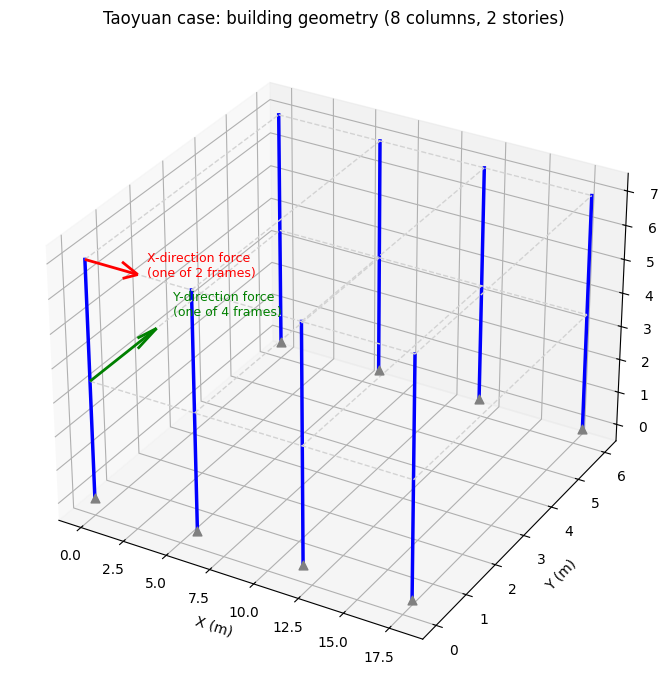

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

xs_grid = [0.0, 6.0, 12.0, 18.0]   # X向4個柱列位置
ys_grid = [0.0, 6.0]                # Y向2個柱列位置
zs_grid = [0.0, h1, h1+h2]          # 基礎, 1F, 屋頂

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# 8根柱子(垂直線)
for x in xs_grid:
    for y in ys_grid:
        ax.plot([x, x], [y, y], [0, h1+h2], 'b-', lw=2.5, zorder=2)
        ax.scatter([x], [y], [0], color='gray', s=40, marker='^', zorder=5)

# 樓層平面參考線(僅示意, 非分析模型元素)
for z in [h1, h1+h2]:
    for y in ys_grid:
        ax.plot(xs_grid, [y]*len(xs_grid), [z]*len(xs_grid), color='lightgray', lw=1, ls='--')
    for x in xs_grid:
        ax.plot([x]*len(ys_grid), ys_grid, [z]*len(ys_grid), color='lightgray', lw=1, ls='--')

# X向力示意箭頭(作用在y=0這一排, 代表其中一榀X向構架)
ax.quiver(0, 0, h1+h2, 3, 0, 0, color='red', arrow_length_ratio=0.3, lw=2)
ax.text(3.5, 0, h1+h2, 'X-direction force\n(one of 2 frames)', color='red', fontsize=9)

# Y向力示意箭頭(作用在x=0這一排, 代表其中一榀Y向構架)
ax.quiver(0, 0, h1, 0, 2, 0, color='green', arrow_length_ratio=0.3, lw=2)
ax.text(0, 2.5, h1, 'Y-direction force\n(one of 4 frames)', color='green', fontsize=9)

ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
ax.set_title('Taoyuan case: building geometry (8 columns, 2 stories)')
plt.tight_layout()
plt.show()

## 第 9 課:X 向、Y 向各自的變形圖

跟 Case-02/03 一樣的畫法,分別畫出兩個方向構架(用 20cm 柱, Design
Loop 收斂值)的未變形/變形對比。這兩張圖是「真的算過的東西」,跟
上一課的 3D 示意圖性質不同。

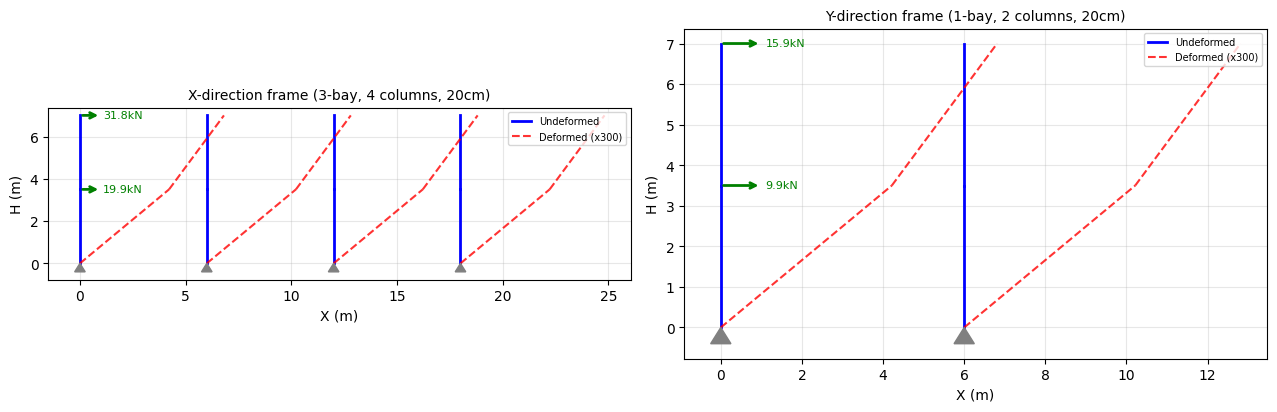

In [10]:
def get_frame_geometry(h_col, E_mat, span, n_bay, F1_frame, F2_frame):
    """重新建模並擷取完整節點座標+位移, 供繪圖用"""
    Ic = h_col**4/12
    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)
    xs = [i*(span/n_bay) for i in range(n_bay+1)]
    base_nodes, f1_nodes, roof_nodes = [], [], []
    nid = 1
    for x in xs:
        ops.node(nid, x, 0.0); ops.fix(nid,1,1,1); base_nodes.append((nid,x,0.0)); nid+=1
    for x in xs:
        ops.node(nid, x, h1); ops.fix(nid,0,1,1); f1_nodes.append((nid,x,h1)); nid+=1
    for x in xs:
        ops.node(nid, x, h1+h2); ops.fix(nid,0,1,1); roof_nodes.append((nid,x,h1+h2)); nid+=1
    for n,_,_ in f1_nodes[1:]:
        ops.equalDOF(f1_nodes[0][0], n, 1)
    for n,_,_ in roof_nodes[1:]:
        ops.equalDOF(roof_nodes[0][0], n, 1)
    A_big = 1.0e6
    ops.geomTransf('Linear', 1)
    eid = 1
    elems = []
    for (b,xb,yb),(f,xf,yf) in zip(base_nodes, f1_nodes):
        ops.element('elasticBeamColumn', eid, b, f, A_big, E_mat, Ic, 1); elems.append((b,f)); eid+=1
    for (f,xf,yf),(r,xr,yr) in zip(f1_nodes, roof_nodes):
        ops.element('elasticBeamColumn', eid, f, r, A_big, E_mat, Ic, 1); elems.append((f,r)); eid+=1
    ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
    ops.load(f1_nodes[0][0], F1_frame, 0.0, 0.0)
    ops.load(roof_nodes[0][0], F2_frame, 0.0, 0.0)
    ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Transformation')
    ops.test('NormDispIncr', 1e-10, 20); ops.algorithm('Newton')
    ops.integrator('LoadControl', 1.0); ops.analysis('Static'); ops.analyze(1)

    all_nodes = base_nodes + f1_nodes + roof_nodes
    node_xy = {n: (x, y) for n, x, y in all_nodes}
    disp = {n: (ops.nodeDisp(n,1), ops.nodeDisp(n,2)) for n, _, _ in all_nodes}
    fixed = [n for n, _, _ in base_nodes]
    loaded = {f1_nodes[0][0]: F1_frame, roof_nodes[0][0]: F2_frame}
    return node_xy, elems, fixed, loaded, disp


def plot_frame(ax, node_xy, elems, fixed, loaded, disp, scale, title):
    for ni, nj in elems:
        xi, yi = node_xy[ni]; xj, yj = node_xy[nj]
        ax.plot([xi, xj], [yi, yj], 'b-', lw=2, zorder=2,
                 label='Undeformed' if (ni,nj)==elems[0] else None)
        xdi = xi+disp[ni][0]*scale; ydi = yi+disp[ni][1]*scale
        xdj = xj+disp[nj][0]*scale; ydj = yj+disp[nj][1]*scale
        ax.plot([xdi, xdj], [ydi, ydj], 'r--', lw=1.5, alpha=0.8, zorder=3,
                 label=f'Deformed (x{scale})' if (ni,nj)==elems[0] else None)
    for n in fixed:
        x, y = node_xy[n]
        tri = plt.Polygon([(x-0.25,y-0.4),(x+0.25,y-0.4),(x,y)], closed=True, color='gray', zorder=5)
        ax.add_patch(tri)
    for n, f in loaded.items():
        x, y = node_xy[n]
        ax.annotate('', xy=(x+1.0,y), xytext=(x,y), arrowprops=dict(arrowstyle='->', color='green', lw=2))
        ax.text(x+1.1, y, f'{f:.1f}kN', color='green', fontsize=8, va='center')
    ax.set_aspect('equal'); ax.set_title(title, fontsize=10)
    ax.set_xlabel('X (m)'); ax.set_ylabel('H (m)')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)


nxy_X, el_X, fix_X, load_X, disp_X = get_frame_geometry(0.20, E_rc, 18.0, 3, F1_X, F2_X)
nxy_Y, el_Y, fix_Y, load_Y, disp_Y = get_frame_geometry(0.20, E_rc, 6.0, 1, F1_Y, F2_Y)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_frame(axes[0], nxy_X, el_X, fix_X, load_X, disp_X, scale=300,
           title='X-direction frame (3-bay, 4 columns, 20cm)')
plot_frame(axes[1], nxy_Y, el_Y, fix_Y, load_Y, disp_Y, scale=300,
           title='Y-direction frame (1-bay, 2 columns, 20cm)')
plt.tight_layout()
plt.show()

## 總結表

In [11]:
print("="*55)
print("Case-04 桃園案例結果總結")
print("="*55)
print(f"{'整棟樓F1/F2':<24}{F1_total}/{F2_total} kN")
print(f"{'X向單榀力(3跨4柱)':<24}{F1_X:.2f}/{F2_X:.2f} kN")
print(f"{'Y向單榀力(1跨2柱)':<24}{F1_Y:.2f}/{F2_Y:.2f} kN")
print(f"{'40cm柱X向Mu':<24}{demand_X_40.Mu:.3f} kN-m")
print(f"{'反曲點法估計(第15課)':<24}22.61 kN-m")
print(f"{'X向Design Loop收斂':<24}{size_X*100:.0f}cm")
print(f"{'Y向Design Loop收斂':<24}{size_Y*100:.0f}cm")
print(f"{'兩方向需求是否相同':<24}是(剪力構架假設下的已知侷限, 待Case-05驗證)")
print()
print("Case-04 [PASS] -- 可以進到 Case-05(三維RC, 驗證方向性差異與樓板剛性假設)")

Case-04 桃園案例結果總結
整棟樓F1/F2                39.75/63.6 kN
X向單榀力(3跨4柱)             19.88/31.80 kN
Y向單榀力(1跨2柱)             9.94/15.90 kN
40cm柱X向Mu               22.608 kN-m
反曲點法估計(第15課)            22.61 kN-m
X向Design Loop收斂         20cm
Y向Design Loop收斂         20cm
兩方向需求是否相同               是(剪力構架假設下的已知侷限, 待Case-05驗證)

Case-04 [PASS] -- 可以進到 Case-05(三維RC, 驗證方向性差異與樓板剛性假設)
